# kütüphaneleri import etme

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# data yükleme

In [109]:
df_train = pd.read_csv("C:\\Users\\İlyas\\OneDrive\\Belgeler\\veri setleri ve vs code çalışmaları\\Spaceship Titanic\\train.csv")
df_test = pd.read_csv("C:\\Users\\İlyas\\OneDrive\\Belgeler\\veri setleri ve vs code çalışmaları\\Spaceship Titanic\\test.csv")

# basit inceleme ve görselleştirme

In [110]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [111]:
df_train.shape

(8693, 14)

In [112]:
df_train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [113]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [114]:
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [115]:
df_train.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [116]:
corr = df_train.corr(numeric_only=True)
corr

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.207075
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,1.000000


<Axes: >

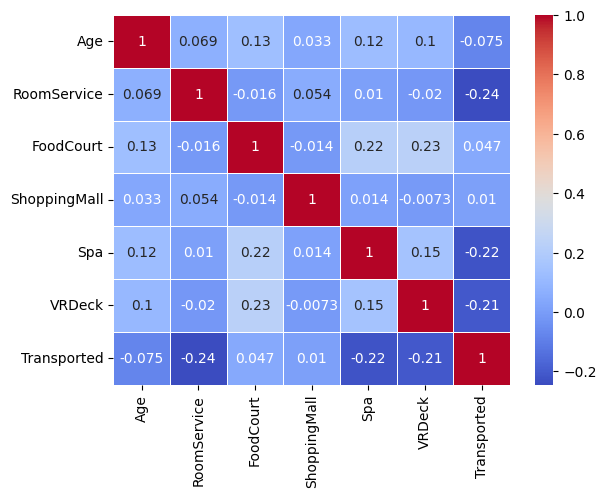

In [117]:
sns.heatmap(data=corr, annot=True, cmap="coolwarm",linewidths=0.5)

In [118]:
Hvtd = ["HomePlanet", "VIP", "Transported", "Destination"]

for vc in Hvtd:
    print("___________________________")
    print(f"\n{vc} sütunu : ")
    print("---------------------------")
    print(df_train[vc].value_counts())

___________________________

HomePlanet sütunu : 
---------------------------
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64
___________________________

VIP sütunu : 
---------------------------
VIP
False    8291
True      199
Name: count, dtype: int64
___________________________

Transported sütunu : 
---------------------------
Transported
True     4378
False    4315
Name: count, dtype: int64
___________________________

Destination sütunu : 
---------------------------
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64


In [119]:
Hvd = ["HomePlanet", "VIP", "Destination"]

for Relation in Hvd:
    print(f"\n'{Relation}' sütunu ile 'Transported' arasındaki ilişki:")
    print("------------------------------------------------------")
    print(pd.crosstab(df_train[Relation], df_train['Transported']))


'HomePlanet' sütunu ile 'Transported' arasındaki ilişki:
------------------------------------------------------
Transported  False  True 
HomePlanet               
Earth         2651   1951
Europa         727   1404
Mars           839    920

'VIP' sütunu ile 'Transported' arasındaki ilişki:
------------------------------------------------------
Transported  False  True 
VIP                      
False         4093   4198
True           123     76

'Destination' sütunu ile 'Transported' arasındaki ilişki:
------------------------------------------------------
Transported    False  True 
Destination                
55 Cancri e      702   1098
PSO J318.5-22    395    401
TRAPPIST-1e     3128   2787


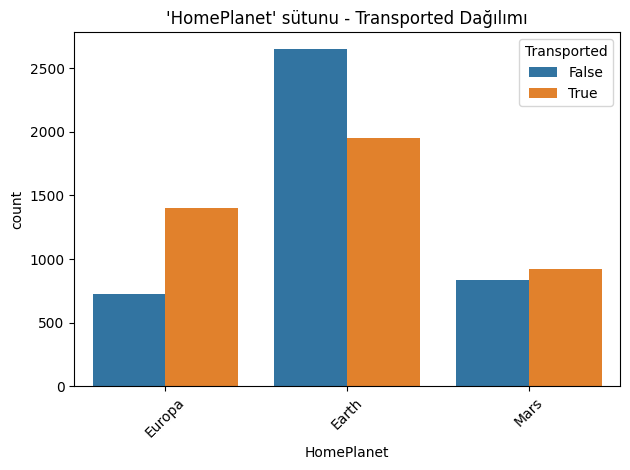

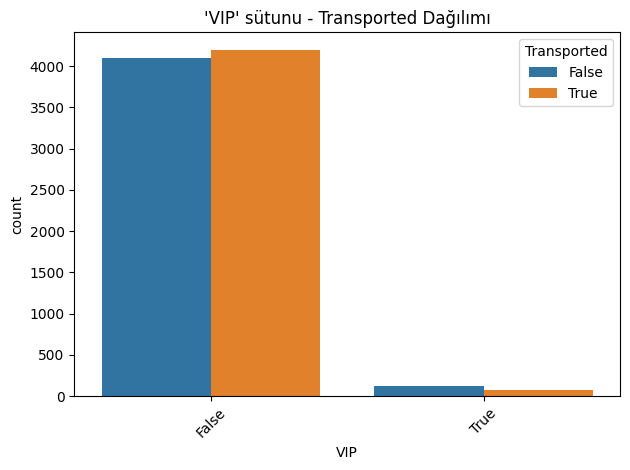

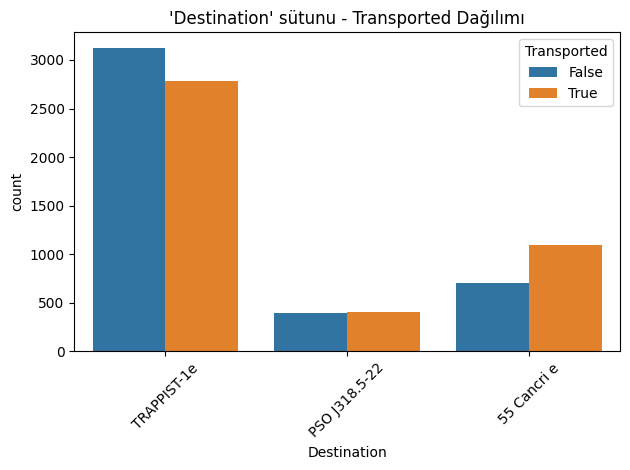

In [120]:
for column1 in Hvd:
    sns.countplot(data=df_train, x=column1, hue="Transported")
    plt.title(f"'{column1}' sütunu - Transported Dağılımı")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

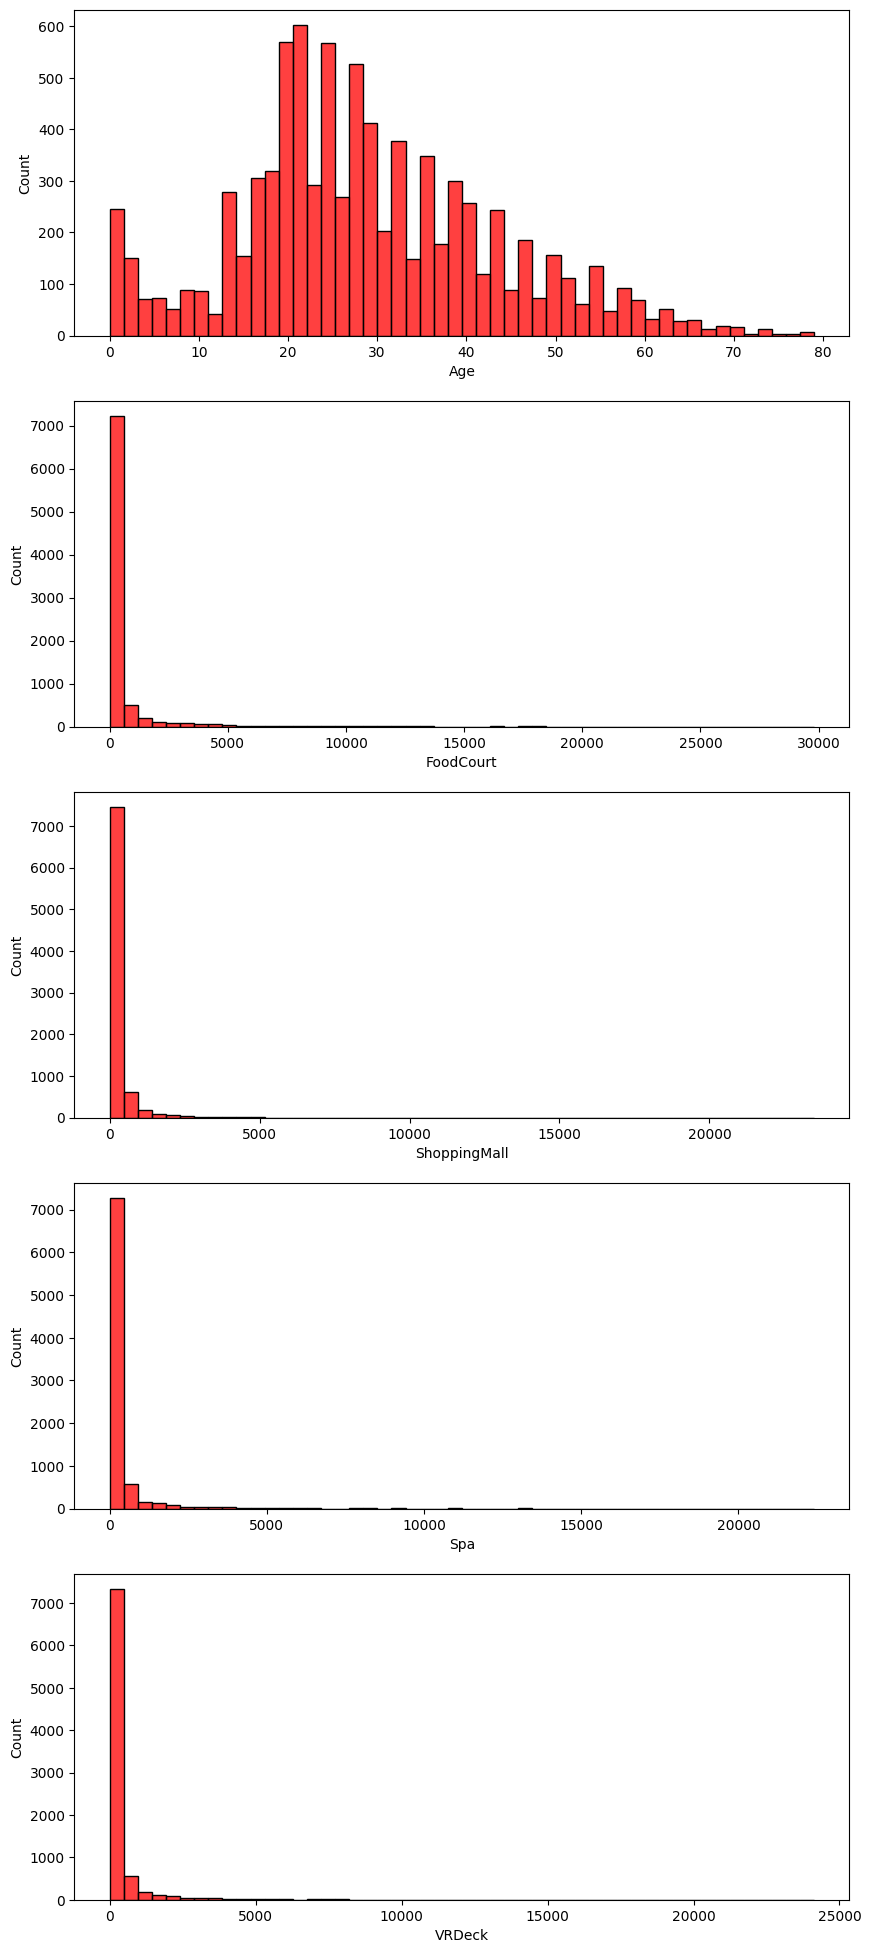

In [121]:
fig, ax = plt.subplots(5,1,  figsize=(10, 10))
plt.subplots_adjust(top = 2)

sns.histplot(df_train['Age'], color='r', bins=50, ax=ax[0]);
sns.histplot(df_train['FoodCourt'], color='r', bins=50, ax=ax[1]);
sns.histplot(df_train['ShoppingMall'], color='r', bins=50, ax=ax[2]);
sns.histplot(df_train['Spa'], color='r', bins=50, ax=ax[3]);
sns.histplot(df_train['VRDeck'], color='r', bins=50, ax=ax[4]);

# **Modelleme**

In [122]:
def split_cabin(df):
    df[["Deck", "Cabin_num", "Side"]] = df["Cabin"].str.split('/', expand=True)
    df.drop(["Cabin"], axis=1, inplace=True)
    return df

In [123]:
def fill_missing_values(df):
     
    for col in ["Deck", "Side"]:
        df[col] = df[col].fillna(df[col].mode()[0])
    
     
    non_nan_cabin_nums = df["Cabin_num"].dropna().unique()
    df["Cabin_num"] = df["Cabin_num"].apply(
        lambda x: np.random.choice(non_nan_cabin_nums) if pd.isna(x) else x
    )
    df["Cabin_num"] = df["Cabin_num"].astype(int)

    
    spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for col in spending_cols:
        df[col] = df[col].fillna(0)

     
    df["Age"] = df["Age"].fillna(df["Age"].median())

     
    cat_cols = ["HomePlanet", "CryoSleep", "VIP", "Destination"]
    for col in cat_cols:
        df[col] = df[col].fillna("Unknown")

    return df

In [124]:
def convert_to_int(df):
    cols_to_convert = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for col in cols_to_convert:
        df[col] = df[col].astype(int)
    return df

In [125]:
def label_encode(df):
    le = LabelEncoder()
    cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side"]
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    if 'Transported' in df.columns:
        df["Transported"] = le.fit_transform(df["Transported"].astype(int))
    return df

In [126]:
yolcu_numarası_test = df_test["PassengerId"].copy()

In [127]:
def drop_val(df):
 for x in ["PassengerId", "Name"]:
     df.drop(x, axis = 1, inplace = True)

 return df

In [128]:
def preprocess_data(df):
    df = split_cabin(df)
    df = fill_missing_values(df)
    df = convert_to_int(df)
    df = label_encode(df)
    df = drop_val(df)
    return df

In [129]:
df_train = preprocess_data(df_train)

In [130]:
df_test = preprocess_data(df_test)

# model olluşturma

In [ ]:
X = df_train.drop("Transported", axis = 1)  # burada train veri setinden transported sütununu yani tahmin etmek istediğimiz bağımllı
# değişkeni düşürdük  
y = df_train["Transported"] # burada y ye bağımlı değişkeni atadık 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # train test split ile x ve y ye atama yaptık 

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)  # burada model model parametrelerini belirliyoruz  prametreleri değiştirerek 
# modelden daha iyi sonuçlar alınabilir

In [ ]:
model.fit(X_train, y_train) # burada modeli eğittik 

RandomForestClassifier(random_state=42)

In [ ]:
y_pred =model.predict(X_test)  # burada modeli predict ediyoruz 

In [ ]:
accuracy_score(y_test,y_pred) # burada da predict ettiğimiz x_test = y_pred ile y_testi kullanarak skoru öğreniyoruz 

0.7912593444508338